# Starting GPU session

In [ ]:
import tensorflow as tf

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

TF version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
OK




---



# LSTM for partirioned datasets

In [ ]:
import gc
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GroupKFold, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



## Preproceesing for LSTM

### Reading file

In [ ]:
import pandas as pd

df = pd.read_csv("18sat_fixfinal.csv")

# Preserve the original row order from the eye-tracking file.
# Within each reader/book/page, this is the fixation/event order used by the LSTM.
df["_sequence_order"] = np.arange(len(df))


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463564 entries, 0 to 463563
Data columns (total 30 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   RECORDING_SESSION_LABEL               463564 non-null  object 
 1   TRIAL_INDEX                           463564 non-null  int64  
 2   CURRENT_FIX_X                         463564 non-null  float64
 3   CURRENT_FIX_Y                         463564 non-null  float64
 4   CURRENT_FIX_PUPIL                     463564 non-null  float64
 5   CURRENT_FIX_DURATION                  463564 non-null  int64  
 6   CURRENT_FIX_INTEREST_AREA_ID          251087 non-null  float64
 7   CURRENT_FIX_INTEREST_AREA_LABEL       251087 non-null  object 
 8   CURRENT_FIX_INTEREST_AREA_PIXEL_AREA  251087 non-null  float64
 9   CURRENT_FIX_INTEREST_AREA_RUN_ID      251087 non-null  float64
 10  CURRENT_FIX_INTEREST_AREA_DWELL_TIME  251087 non-null  float64
 11  

### Addition label data

In [ ]:
labels = pd.read_csv("18sat_labels.csv")

label_cols = [
    "subj",
    "book",
    "confidence",
    "difficulty",
    "familiarity",
    "interest",
    "pressured",
    "sleepiness"
]

labels_small = labels[label_cols].copy()

df = df.merge(
    labels_small,
    left_on=["RECORDING_SESSION_LABEL", "book_name"],
    right_on=["subj", "book"],
    how="left",
    suffixes=("", "_label")
)

df = df.drop(columns=["subj", "book_label"], errors="ignore")

print("Missing label values:")
print(df[["confidence", "difficulty", "familiarity", "interest", "pressured", "sleepiness"]].isna().sum())

Missing label values:
confidence     0
difficulty     0
familiarity    0
interest       0
pressured      0
sleepiness     0
dtype: int64


### Data cleaning

* dropping null values
* dropping unwanted columns

In [ ]:
# Handle missing blink data (null duration implies 0ms)
df['PREVIOUS_SAC_BLINK_DURATION'] = df['PREVIOUS_SAC_BLINK_DURATION'].fillna(0)

# Standardize blink indicators to a binary (1 or 0) format for the network
df['PREVIOUS_SAC_CONTAINS_BLINK'] = (
    df['PREVIOUS_SAC_CONTAINS_BLINK']
    .astype(str)
    .str.lower()
    .map({'true': 1, 'false': 0, '1': 1, '0': 0})
    .fillna(0)
    .astype(int)
)

In [ ]:
# Remove administrative data and categorical labels which are not used by the sequential Bi-LSTM
cols_to_drop = [
    'Session_Name_',
    'Trial_Index_',
    'Trial_Recycled_',
    'page_name',
    'book_name',
    'CURRENT_FIX_INTEREST_AREA_LABEL',
    'CURRENT_FIX_INTEREST_AREA_PIXEL_AREA',
    'TRIAL_INDEX',
    'total_page'
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

### Question-Readung partition and merging with accuracy

In [ ]:
# Extracting comprehension question events and evaluating the accuracy
question_mask = df['type'].str.lower() == 'question'
df.loc[question_mask, 'is_correct'] = (df.loc[question_mask, 'answer'].astype(str) == df.loc[question_mask, 'correct_answer'].astype(str)).astype(float)
unique_answers = df[question_mask].drop_duplicates(subset=['RECORDING_SESSION_LABEL', 'book', 'page'])

# Aggregate total correct answers per participant-book pair
accuracy_scores = unique_answers.groupby(['RECORDING_SESSION_LABEL', 'book'])['is_correct'].sum().reset_index()

# Normalizing to a 0-1 range (each text has exactly 5 comprehension questions)
accuracy_scores['is_correct'] = accuracy_scores['is_correct'] / 5.0
accuracy_scores.rename(columns={'is_correct': 'target_accuracy'}, inplace=True)

# Mapping the computed regression target back to all chronological reading frames
if 'target_accuracy' in df.columns:
    df = df.drop(columns=['target_accuracy'])
df = df.merge(accuracy_scores, on=['RECORDING_SESSION_LABEL', 'book'], how='left')

### LSTM preparations

In [ ]:
#  One-hot encoding categorical saccade directions for network compatibility
df = pd.get_dummies(df, columns=['PREVIOUS_SAC_DIRECTION'], dummy_na=True, dtype=int)

# Dropping intermediate answer features to prevent target leakage during training
df = df.drop(columns=['answer', 'correct_answer', 'is_correct'])

In [ ]:
# Enforcing strict chronological alignment for temporal feature engineering
df = df.sort_values(by=['RECORDING_SESSION_LABEL', 'book', 'page', '_sequence_order'])

# Aggregating cumulative saccade directions per reading section
saccade_cols = [c for c in df.columns if c.startswith('PREVIOUS_SAC_DIRECTION_')]
for col in saccade_cols:
    df[f'total_{col}'] = df.groupby(['RECORDING_SESSION_LABEL', 'book', 'page'])[col].transform('sum')

# Computing blink frequencies and duration-normalized blink rates
df['total_blinks'] = df.groupby(['RECORDING_SESSION_LABEL', 'book', 'page'])['PREVIOUS_SAC_CONTAINS_BLINK'].transform('sum')
df['blink_rate_by_RT'] = df['total_blinks'] / (df['RT'] + 1e-6)  #Epsilon og 1e-6 added for numerical stability

# Aggregating overall fixation dwell time
df['total_dwell_time'] = df.groupby(['RECORDING_SESSION_LABEL', 'book', 'page'])['CURRENT_FIX_DURATION'].transform('sum')

# Aggregating overall fixation dwell time
df['total_dwell_time'] = df.groupby(['RECORDING_SESSION_LABEL', 'book', 'page'])['CURRENT_FIX_DURATION'].transform('sum')

In [ ]:
feature_categories = {
    'pupil_blink': [
        'CURRENT_FIX_PUPIL',
        'pupil_change',
        'PREVIOUS_SAC_CONTAINS_BLINK',
        'PREVIOUS_SAC_BLINK_DURATION',
        'total_blinks',
        'blink_rate_by_RT'
    ],
    'fixation': [
        'CURRENT_FIX_X',
        'CURRENT_FIX_Y',
        'CURRENT_FIX_DURATION',
        'CURRENT_FIX_INTEREST_AREA_ID',
        'CURRENT_FIX_INTEREST_AREA_RUN_ID',
        'CURRENT_FIX_INTEREST_AREA_DWELL_TIME',
        'total_dwell_time',
        'RT'
    ],
    'saccade': [
        'PREVIOUS_SAC_ANGLE',
        'PREVIOUS_SAC_AMPLITUDE',
        'PREVIOUS_SAC_AVG_VELOCITY'
    ] + saccade_dir_cols + total_dir_cols,
}

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Flattening hierarchical feature dictionary and replacing nulls with 0s to maintain matrix integrity
all_features = [feat for category in feature_categories.values() for feat in category]
df[all_features] = df[all_features].fillna(0)
df = df.dropna(subset=['target_accuracy'])



# Classification pipeline for partitioned datasets

The regression Bi-LSTM was replaced with a 3-class classification Bi-LSTM.

For every low/high subset, the pipeline now performs:

1. grouped reader split;
2. scaling fitted only on training readers;
3. PCA fitted separately for pupil/blink, fixation, and saccade groups;
4. conversion of comprehension scores into three classes: LOW (0%–20%), MEDIUM (40%–60%), and HIGH (80%–100%);
5. grouped cross-validation of the full three-component model;
6. classification ablation by removing one PCA component at a time;
7. evaluation with accuracy, balanced accuracy, and macro F1.

A positive accuracy drop means that removing the group harmed classification performance.

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Masking, Bidirectional, LSTM, Dense, Dropout

MASK_VALUE = -999.0
N_CLASSES = 3
RANDOM_BASELINE_ACCURACY = 1.0 / N_CLASSES


def to_class_labels(y):
    """
    Map comprehension scores to three classes:
    0 = LOW (0.0, 0.2)
    1 = MEDIUM (0.4, 0.6)
    2 = HIGH (0.8, 1.0)
    """
    scores = np.asarray(y, dtype=float)

    if np.any((scores < 0.0) | (scores > 1.0)):
        raise ValueError("target_accuracy values must be between 0 and 1.")

    return np.select([scores <= 0.2, scores <= 0.6], [0, 1], default=2).astype(int)


def build_classification_rnn(timesteps, features):
    """Classification architecture supplied in the updated baseline notebook."""
    inputs = Input(shape=(timesteps, features))
    x = Masking(mask_value=MASK_VALUE)(inputs)
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.1))(x)
    x = Bidirectional(LSTM(32, dropout=0.1))(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.1)(x)
    outputs = Dense(N_CLASSES, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def make_class_weights(y):
    """Balanced weights for classes that are present in the current training fold."""
    present_classes = np.unique(y)
    weights = compute_class_weight(class_weight='balanced', classes=present_classes, y=y)
    return {int(cls): float(weight) for cls, weight in zip(present_classes, weights)}

In [ ]:
def run_classification_pipeline(df_subset, subset_name, n_splits=3, random_state=42, epochs=30, batch_size=32):
    print("\n" + "=" * 90)
    print(f"CLASSIFICATION PIPELINE: {subset_name}")
    print("=" * 90)

    df_subset = df_subset.copy()
    df_subset = df_subset.dropna(subset=["target_accuracy"])
    df_subset[all_features] = (df_subset[all_features].replace([np.inf, -np.inf], np.nan).fillna(0))

    required_columns = [
        "RECORDING_SESSION_LABEL",
        "book",
        "page",
        "target_accuracy",
        "_sequence_order"
    ]
    missing_columns = [c for c in required_columns if c not in df_subset.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    # Explicit chronological order inside every reader-book sequence
    df_subset = df_subset.sort_values(["RECORDING_SESSION_LABEL", "book", "page", "_sequence_order"]).reset_index(drop=True)

    participants = np.asarray(df_subset["RECORDING_SESSION_LABEL"].unique())
    if len(participants) < max(n_splits, 3):
        print(
            f"Only {len(participants)} participants; "
            f"need at least {max(n_splits, 3)}. Skipping."
        )
        return None

    def set_all_seeds(seed):
        import random
        random.seed(seed)
        np.random.seed(seed)
        tf.random.set_seed(seed)

    set_all_seeds(random_state)


    def check_targets(dataframe):
        target_counts = (dataframe.groupby(["RECORDING_SESSION_LABEL", "book"])["target_accuracy"].nunique(dropna=True))
        inconsistent = target_counts[target_counts != 1]
        if not inconsistent.empty:
            raise ValueError(
                "target_accuracy is not constant inside some reader-book groups: "
                f"{inconsistent.index.tolist()[:5]}"
            )

    def make_sequence_metadata(dataframe):
        check_targets(dataframe)
        metadata = (dataframe.groupby(["RECORDING_SESSION_LABEL", "book"], sort=False)["target_accuracy"].first().reset_index())
        metadata["target_class"] = to_class_labels(metadata["target_accuracy"].to_numpy())
        return metadata

    def rows_for_metadata(dataframe, metadata):
        keys = metadata[["RECORDING_SESSION_LABEL", "book"]].drop_duplicates()
        return dataframe.merge(keys,on=["RECORDING_SESSION_LABEL", "book"],how="inner").sort_values(["RECORDING_SESSION_LABEL", "book", "page", "_sequence_order"])

    def fit_preprocessing(train_rows, kept_groups):
        selected_features = [feature for group_name in kept_groups for feature in feature_categories[group_name]]

        scaler = StandardScaler()
        scaled_train = train_rows.copy()
        scaled_train[selected_features] = scaler.fit_transform(train_rows[selected_features])

        pca_models = {}
        for group_name in kept_groups:
            group_features = feature_categories[group_name]
            pca = PCA(n_components=1)
            pca.fit(scaled_train[group_features])
            pca_models[group_name] = pca

        return scaler, pca_models, selected_features

    def transform_rows(dataframe, scaler, pca_models, selected_features, kept_groups):
        transformed = dataframe.copy()
        transformed[selected_features] = scaler.transform(transformed[selected_features])

        pca_columns = []
        for group_name in kept_groups:
            column_name = f"pca_{group_name}"
            transformed[column_name] = (pca_models[group_name].transform(transformed[feature_categories[group_name]]).ravel())
            pca_columns.append(column_name)

        return transformed, pca_columns

    def build_sequences(dataframe, feature_list):
        sequences, targets, groups = [], [], []

        for (session, book), group_df in dataframe.groupby(["RECORDING_SESSION_LABEL", "book"],sort=False):
            group_df = group_df.sort_values(["page", "_sequence_order"])

            unique_targets = (group_df["target_accuracy"].dropna().unique())
            if len(unique_targets) != 1:
                raise ValueError(f"Inconsistent target for reader={session}, book={book}")

            sequences.append(group_df[feature_list].to_numpy(dtype="float32"))
            targets.append(unique_targets[0])
            groups.append(session)

        if not sequences:
            raise ValueError("No sequences were created.")

        return (sequences, to_class_labels(targets), np.asarray(groups))

    def pad_train_other(train_sequences, other_sequences):
        # Validation and holdout do not influence the input length.
        max_len = max(len(seq) for seq in train_sequences)

        X_train = pad_sequences(train_sequences, maxlen=max_len, padding="post", truncating="post", dtype="float32", value=MASK_VALUE)
        X_other = pad_sequences(other_sequences, maxlen=max_len, padding="post", truncating="post", dtype="float32", value=MASK_VALUE)
        return X_train, X_other

    def calculate_metrics(y_true, y_pred):
        return {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
            "macro_f1": float(f1_score(y_true, y_pred, labels=np.arange(N_CLASSES), average="macro", zero_division=0))
        }

    def create_grouped_splits(metadata, requested_splits, seed):
        actual_splits = min(requested_splits, metadata["RECORDING_SESSION_LABEL"].nunique())
        if actual_splits < 2:
            raise ValueError("Not enough readers for grouped validation.")

        X_dummy = np.zeros((len(metadata), 1))
        y = metadata["target_class"].to_numpy()
        groups = metadata["RECORDING_SESSION_LABEL"].to_numpy()

        try:
            splitter = StratifiedGroupKFold(n_splits=actual_splits, shuffle=True, random_state=seed)
            return list(splitter.split(X_dummy, y, groups))
        except ValueError as error:
            print(
                "Warning: StratifiedGroupKFold could not be used; "
                f"falling back to GroupKFold. Reason: {error}"
            )
            splitter = GroupKFold(n_splits=actual_splits)
            return list(splitter.split(X_dummy, y, groups))

    def train_fold(train_rows, val_rows, kept_groups, seed):
        K.clear_session()
        gc.collect()
        set_all_seeds(seed)

        scaler, pca_models, selected_features = fit_preprocessing(train_rows, kept_groups)
        transformed_train, feature_list = transform_rows(train_rows, scaler, pca_models, selected_features, kept_groups)
        transformed_val, _ = transform_rows(val_rows, scaler, pca_models, selected_features, kept_groups)

        train_sequences, y_train, _ = build_sequences(transformed_train, feature_list)
        val_sequences, y_val, _ = build_sequences(transformed_val, feature_list)

        X_train, X_val = pad_train_other(train_sequences, val_sequences)

        model = build_classification_rnn(X_train.shape[1], X_train.shape[2])
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, class_weight=make_class_weights(y_train), verbose=0,
            callbacks=[
                EarlyStopping(
                    monitor="val_loss",
                    patience=4,
                    restore_best_weights=True
                )
            ]
        )

        val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
        metrics = calculate_metrics(y_val, val_pred)
        metrics["best_epoch"] = int(np.argmin(history.history["val_loss"]) + 1)
        return metrics


    # External unseen-reader holdout
    train_subs, test_subs = train_test_split(participants, test_size=0.2, random_state=random_state)

    development_df = df_subset[df_subset["RECORDING_SESSION_LABEL"].isin(train_subs)].copy()
    holdout_df = df_subset[df_subset["RECORDING_SESSION_LABEL"].isin(test_subs)].copy()

    development_metadata = make_sequence_metadata(development_df)
    holdout_metadata = make_sequence_metadata(holdout_df)

    print(f"Development readers: {len(train_subs)}")
    print(f"Holdout readers: {len(test_subs)}")

    development_class_counts = np.bincount(development_metadata["target_class"].to_numpy(), minlength=N_CLASSES)
    holdout_class_counts = np.bincount(holdout_metadata["target_class"].to_numpy(), minlength=N_CLASSES)
    print(
        "Development class counts "
        "[LOW, MEDIUM, HIGH]:",
        development_class_counts
    )
    print(
        "Holdout class counts "
        "[LOW, MEDIUM, HIGH]:",
        holdout_class_counts
    )

    # Baselines computed without using holdout labels for model training.
    development_classes = development_metadata["target_class"].to_numpy()
    majority_class = int(np.argmax(np.bincount(development_classes, minlength=N_CLASSES)))
    holdout_y = holdout_metadata["target_class"].to_numpy()
    majority_pred = np.full(len(holdout_y), majority_class, dtype=int)
    majority_baseline_accuracy = float(accuracy_score(holdout_y, majority_pred))


    # Configurations: full + one group removed at a time
    all_groups = list(feature_categories.keys())
    configurations = {"full": all_groups}
    for dropped_group in all_groups:
        configurations[f"without_{dropped_group}"] = [
            group for group in all_groups
            if group != dropped_group
        ]


    # Stratified grouped cross-validation
    fold_splits = create_grouped_splits(development_metadata, n_splits, random_state)

    cv_records = []

    for fold_number, (train_idx, val_idx) in enumerate(fold_splits, start=1):
        fold_train_metadata = development_metadata.iloc[train_idx]
        fold_val_metadata = development_metadata.iloc[val_idx]

        fold_train_rows = rows_for_metadata(development_df, fold_train_metadata)
        fold_val_rows = rows_for_metadata(development_df, fold_val_metadata)

        # Same seed for full and every ablated model in this fold
        fold_seed = random_state + fold_number

        for config_name, kept_groups in configurations.items():
            metrics = train_fold(fold_train_rows, fold_val_rows, kept_groups, fold_seed)

            cv_records.append({
                "fold": fold_number,
                "configuration": config_name,
                **metrics
            })

            print(
                f"{config_name}, fold {fold_number}: "
                f"accuracy={metrics['accuracy']:.4f}, "
                f"balanced_accuracy={metrics['balanced_accuracy']:.4f}, "
                f"macro_F1={metrics['macro_f1']:.4f}"
            )

    cv_df = pd.DataFrame(cv_records)

    cv_results = {}
    for config_name in configurations:
        config_rows = cv_df[cv_df["configuration"] == config_name]
        cv_results[config_name] = {
            "accuracy": float(config_rows["accuracy"].mean()),
            "balanced_accuracy": float(config_rows["balanced_accuracy"].mean()),
            "macro_f1": float(config_rows["macro_f1"].mean())
        }


    # Select the final number of epochs from the CV runs already completed
    selected_epochs = {}

    for config_name in configurations:
        fold_best_epochs = (cv_df.loc[cv_df["configuration"] == config_name, "best_epoch"].astype(int).tolist())

        selected_epoch = max(1, int(np.median(fold_best_epochs)))

        selected_epochs[config_name] = selected_epoch

        print(
            f"{config_name}: best epochs across CV folds = "
            f"{fold_best_epochs}; selected median epoch = "
            f"{selected_epoch}"
        )

    def train_all_development_and_test(kept_groups, best_epoch, seed):
        K.clear_session()
        gc.collect()
        set_all_seeds(seed)

        scaler, pca_models, selected_features = fit_preprocessing(development_df, kept_groups)
        transformed_development, feature_list = transform_rows(development_df, scaler, pca_models, selected_features, kept_groups)
        transformed_holdout, _ = transform_rows(holdout_df, scaler, pca_models, selected_features, kept_groups)

        development_sequences, y_development, _ = build_sequences(transformed_development, feature_list)
        holdout_sequences, y_holdout, _ = build_sequences(transformed_holdout, feature_list)

        X_development, X_holdout = pad_train_other(development_sequences, holdout_sequences)

        model = build_classification_rnn(X_development.shape[1], X_development.shape[2])
        model.fit(X_development, y_development, epochs=max(1, best_epoch), batch_size=batch_size, class_weight=make_class_weights(y_development), verbose=0)

        holdout_pred = np.argmax(model.predict(X_holdout, verbose=0), axis=1)
        return calculate_metrics(y_holdout, holdout_pred)

    holdout_results = {}

    # Same final seed for all configurations.
    final_seed = random_state

    for config_name, kept_groups in configurations.items():
        best_epoch = selected_epochs[config_name]

        holdout_results[config_name] = (train_all_development_and_test(kept_groups, best_epoch, final_seed))
        holdout_results[config_name]["best_epoch"] = best_epoch

        print(
            f"Holdout {config_name}: "
            f"accuracy={holdout_results[config_name]['accuracy']:.4f}, "
            f"balanced_accuracy="
            f"{holdout_results[config_name]['balanced_accuracy']:.4f}, "
            f"macro_F1={holdout_results[config_name]['macro_f1']:.4f}, "
            f"epochs={best_epoch}"
        )


    #Ablation report
    full_cv = cv_results["full"]
    full_holdout = holdout_results["full"]

    ablation_results = {}

    for group_name in all_groups:
        config_name = f"without_{group_name}"
        ablated_cv = cv_results[config_name]
        ablated_holdout = holdout_results[config_name]

        ablation_results[group_name] = {
            "cv_accuracy": ablated_cv["accuracy"],
            "cv_balanced_accuracy": ablated_cv["balanced_accuracy"],
            "cv_macro_f1": ablated_cv["macro_f1"],
            "accuracy_drop": (full_cv["accuracy"] - ablated_cv["accuracy"]),
            "balanced_accuracy_drop": (full_cv["balanced_accuracy"] - ablated_cv["balanced_accuracy"]),
            "macro_f1_drop": (full_cv["macro_f1"] - ablated_cv["macro_f1"]),
            "holdout_accuracy": ablated_holdout["accuracy"],
            "holdout_balanced_accuracy": (ablated_holdout["balanced_accuracy"]),
            "holdout_macro_f1": ablated_holdout["macro_f1"],
            "holdout_accuracy_drop": (full_holdout["accuracy"] - ablated_holdout["accuracy"]),
            "holdout_balanced_accuracy_drop": (full_holdout["balanced_accuracy"] - ablated_holdout["balanced_accuracy"]),
            "holdout_macro_f1_drop": (full_holdout["macro_f1"] - ablated_holdout["macro_f1"])
        }

    positive_macro_f1_drops = {
        group: values["macro_f1_drop"]
        for group, values in ablation_results.items()
        if values["macro_f1_drop"] > 0
    }

    most_important_group = (max(positive_macro_f1_drops, key=positive_macro_f1_drops.get) if positive_macro_f1_drops else "No clear dominant group")

    print("\nFINAL CLASSIFICATION ABLATION REPORT")
    print(f"Full CV accuracy: {full_cv['accuracy']:.4f}")
    print(
        f"Full CV balanced accuracy: "
        f"{full_cv['balanced_accuracy']:.4f}"
    )
    print(f"Full CV macro F1: {full_cv['macro_f1']:.4f}")
    print(
        f"Full holdout accuracy: "
        f"{full_holdout['accuracy']:.4f}"
    )
    print(
        f"Uniform random baseline: "
        f"{RANDOM_BASELINE_ACCURACY:.4f}"
    )
    print(
        f"Majority-class holdout baseline: "
        f"{majority_baseline_accuracy:.4f}"
    )

    for group, values in ablation_results.items():
        print(
            f"Without {group}: "
            f"CV macro F1={values['cv_macro_f1']:.4f}, "
            f"drop={values['macro_f1_drop']:+.4f}"
        )

    print(
        "Largest observed group contribution "
        "(by CV macro F1 drop):",
        most_important_group
    )

    return {
        "subset": subset_name,
        "rows": len(df_subset),
        "participants": len(participants),
        "full_cv_accuracy": full_cv["accuracy"],
        "full_cv_balanced_accuracy": (full_cv["balanced_accuracy"]),
        "full_cv_macro_f1": full_cv["macro_f1"],
        "full_holdout_accuracy": (full_holdout["accuracy"]),
        "full_holdout_balanced_accuracy": (full_holdout["balanced_accuracy"]),
        "full_holdout_macro_f1": (full_holdout["macro_f1"]),
        "random_baseline_accuracy": (RANDOM_BASELINE_ACCURACY),
        "majority_baseline_accuracy": (majority_baseline_accuracy),
        "ablation_results": ablation_results,
        "most_important_group": most_important_group
    }


## Run the classification pipeline for all subjective low/high partitions

In [ ]:
split_features = [
    'confidence',
    'difficulty',
    'familiarity',
    'interest',
    'pressured',
    'sleepiness'
]

classification_results = []

for split_col in split_features:
    print("\n" + "#" * 90)
    print(f"CLASSIFICATION ABLATION SPLIT BY: {split_col}")
    print("#" * 90)

    temp_df = df.dropna(subset=[split_col]).copy()
    low_df = temp_df[temp_df[split_col].isin([0, 1])].copy()
    high_df = temp_df[temp_df[split_col].isin([2, 3])].copy()

    for subset_df, level in [(low_df, 'LOW 0-1'), (high_df, 'HIGH 2-3')]:
        result = run_classification_pipeline(subset_df, subset_name=f'{split_col}: {level}', n_splits=3)
        if result is not None:
            classification_results.append(result)


##########################################################################################
CLASSIFICATION ABLATION SPLIT BY: confidence
##########################################################################################

CLASSIFICATION PIPELINE: confidence: LOW 0-1
Development readers: 71
Holdout readers: 18
Development class counts [LOW, MEDIUM, HIGH]: [ 33 114  36]
Holdout class counts [LOW, MEDIUM, HIGH]: [ 7 25  4]
full, fold 1: accuracy=0.6271, balanced_accuracy=0.3952, macro_F1=0.3858
without_pupil_blink, fold 1: accuracy=0.6271, balanced_accuracy=0.3246, macro_F1=0.2569


without_fixation, fold 1: accuracy=0.6780, balanced_accuracy=0.3939, macro_F1=0.3692
without_saccade, fold 1: accuracy=0.6441, balanced_accuracy=0.3333, macro_F1=0.2612
full, fold 2: accuracy=0.2667, balanced_accuracy=0.2935, macro_F1=0.2331
without_pupil_blink, fold 2: accuracy=0.3167, balanced_accuracy=0.2776, macro_F1=0.2674
without_fixation, fold 2: accuracy=0.3500, balanced_accuracy=0.3938, macro_F1=0.3215
without_saccade, fold 2: accuracy=0.3167, balanced_accuracy=0.3941, macro_F1=0.2875
full, fold 3: accuracy=0.5000, balanced_accuracy=0.3197, macro_F1=0.2955
without_pupil_blink, fold 3: accuracy=0.5781, balanced_accuracy=0.3246, macro_F1=0.2442
without_fixation, fold 3: accuracy=0.5938, balanced_accuracy=0.3431, macro_F1=0.2800
without_saccade, fold 3: accuracy=0.5938, balanced_accuracy=0.3333, macro_F1=0.2484
full: best epochs across CV folds = [1, 5, 1]; selected median epoch = 1
without_pupil_blink: best epochs across CV folds = [2, 6, 1]; selected median epoch = 2
without_fi

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


full, fold 2: accuracy=0.4545, balanced_accuracy=0.4722, macro_F1=0.2928


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


...

Holdout full: accuracy=0.2667, balanced_accuracy=0.4000, macro_F1=0.1667, epochs=9


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Holdout without_pupil_blink: accuracy=0.3333, balanced_accuracy=0.5000, macro_F1=0.1754, epochs=6
Holdout without_fixation: accuracy=0.1333, balanced_accuracy=0.1000, macro_F1=0.0784, epochs=7


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Holdout without_saccade: accuracy=0.2667, balanced_accuracy=0.4000, macro_F1=0.1569, epochs=8

FINAL CLASSIFICATION ABLATION REPORT
Full CV accuracy: 0.3879
Full CV balanced accuracy: 0.4019
Full CV macro F1: 0.2800
Full holdout accuracy: 0.2667
Uniform random baseline: 0.3333
Majority-class holdout baseline: 0.6667
Without pupil_blink: CV macro F1=0.2772, drop=+0.0028
Without fixation: CV macro F1=0.3123, drop=-0.0323
Without saccade: CV macro F1=0.3532, drop=-0.0731
Largest observed group contribution (by CV macro F1 drop): pupil_blink

##########################################################################################
CLASSIFICATION ABLATION SPLIT BY: interest
##########################################################################################

CLASSIFICATION PIPELINE: interest: LOW 0-1
Development readers: 64
Holdout readers: 16
Development class counts [LOW, MEDIUM, HIGH]: [17 76 23]
Holdout class counts [LOW, MEDIUM, HIGH]: [12 13  9]
full, fold 1: accuracy=0.4138, b

## Classification ablation summary

In [ ]:
summary_rows = []

for result in classification_results:
    row = {
        'subset': result['subset'],
        'rows': result['rows'],
        'participants': result['participants'],
        'full_cv_accuracy': result['full_cv_accuracy'],
        'full_cv_balanced_accuracy': result['full_cv_balanced_accuracy'],
        'full_cv_macro_f1': result['full_cv_macro_f1'],
        'full_holdout_accuracy': result['full_holdout_accuracy'],
        'full_holdout_balanced_accuracy': result['full_holdout_balanced_accuracy'],
        'full_holdout_macro_f1': result['full_holdout_macro_f1'],
        'random_baseline_accuracy': result['random_baseline_accuracy'],
        'majority_baseline_accuracy': result['majority_baseline_accuracy'],
        'most_important_group': result['most_important_group']
    }

    for group_name, metrics in result['ablation_results'].items():
        row[f'accuracy_without_{group_name}'] = metrics['cv_accuracy']
        row[f'accuracy_drop_without_{group_name}'] = metrics['accuracy_drop']
        row[f'balanced_accuracy_drop_without_{group_name}'] = metrics['balanced_accuracy_drop']
        row[f'macro_f1_drop_without_{group_name}'] = metrics['macro_f1_drop']

        row[f'holdout_accuracy_without_{group_name}'] = metrics['holdout_accuracy']
        row[f'holdout_accuracy_drop_without_{group_name}'] = metrics['holdout_accuracy_drop']
        row[f'holdout_balanced_accuracy_drop_without_{group_name}'] = metrics['holdout_balanced_accuracy_drop']
        row[f'holdout_macro_f1_drop_without_{group_name}'] = metrics['holdout_macro_f1_drop']

    summary_rows.append(row)

classification_summary_df = pd.DataFrame(summary_rows)
classification_summary_df


,subset,rows,participants,full_cv_accuracy,full_cv_balanced_accuracy,full_cv_macro_f1,full_holdout_accuracy,full_holdout_balanced_accuracy,full_holdout_macro_f1,random_baseline_accuracy,...,holdout_balanced_accuracy_drop_without_fixation,holdout_macro_f1_drop_without_fixation,accuracy_without_saccade,accuracy_drop_without_saccade,balanced_accuracy_drop_without_saccade,macro_f1_drop_without_saccade,holdout_accuracy_without_saccade,holdout_accuracy_drop_without_saccade,holdout_balanced_accuracy_drop_without_saccade,holdout_macro_f1_drop_without_saccade
0,confidence: LOW 0-1,276354,89,0.464595,0.336150,0.304796,0.333333,0.401429,0.333333,0.333333,...,0.043333,0.062500,0.518161,-0.053566,-0.017442,0.039118,0.361111,-0.027778,0.159524,0.107448
1,confidence: HIGH 2-3,187210,80,0.354167,0.286588,0.218577,0.250000,0.493284,0.258182,0.333333,...,0.175824,0.020087,0.329365,0.024802,-0.069978,-0.002187,0.416667,-0.166667,0.255189,0.058182
2,difficulty: LOW 0-1,304462,93,0.363451,0.314123,0.259985,0.407407,0.357843,0.279404,0.333333,...,-0.001225,-0.017202,0.392796,-0.029345,-0.020350,-0.032618,0.370370,0.037037,0.002451,0.045126
3,difficulty: HIGH 2-3,159102,76,0.471717,0.345732,0.305061,0.545455,0.342593,0.297165,0.333333,...,0.120370,0.051551,0.527182,-0.055464,-0.027803,-0.020634,0.363636,0.181818,0.064815,0.039919
4,familiarity: LOW 0-1,355244,94,0.437085,0.313670,0.287215,0.396226,0.378086,0.362350,0.333333,...,-0.054012,-0.037265,0.500605,-0.063520,-0.042894,-0.031477,0.358491,0.037736,0.012346,0.011812
5,familiarity: HIGH 2-3,108320,60,0.387879,0.401852,0.280028,0.266667,0.400000,0.166667,0.333333,...,0.300000,0.088235,0.455556,-0.067677,-0.082099,-0.073135,0.266667,0.000000,0.000000,0.009804
6,interest: LOW 0-1,180734,80,0.307612,0.391005,0.276030,0.441176,0.418803,0.339893,0.333333,...,0.070513,-0.018953,0.405454,-0.097842,0.047200,-0.034276,0.558824,-0.117647,-0.136040,-0.210919
7,interest: HIGH 2-3,282830,91,0.383682,0.283723,0.250059,0.304348,0.230359,0.253133,0.333333,...,0.062357,0.130448,0.422201,-0.038519,-0.042499,-0.059982,0.456522,-0.152174,-0.233028,-0.157932
8,pressured: LOW 0-1,289957,83,0.380136,0.427202,0.342859,0.351852,0.282407,0.284776,0.333333,...,-0.080688,-0.014298,0.382700,-0.002564,-0.009842,-0.000858,0.388889,-0.037037,-0.007275,0.002958
9,pressured: HIGH 2-3,173607,54,0.336458,0.272036,0.244471,0.166667,0.219608,0.123994,0.333333,...,-0.147059,-0.046296,0.497815,-0.161358,-0.076248,-0.077640,0.208333,-0.041667,-0.019608,-0.067673


In [ ]:
classification_summary_df.to_csv('classification_ablation_results.csv', index=False)
print('Saved: classification_ablation_results.csv')

Saved: classification_ablation_results.csv


## Visualization

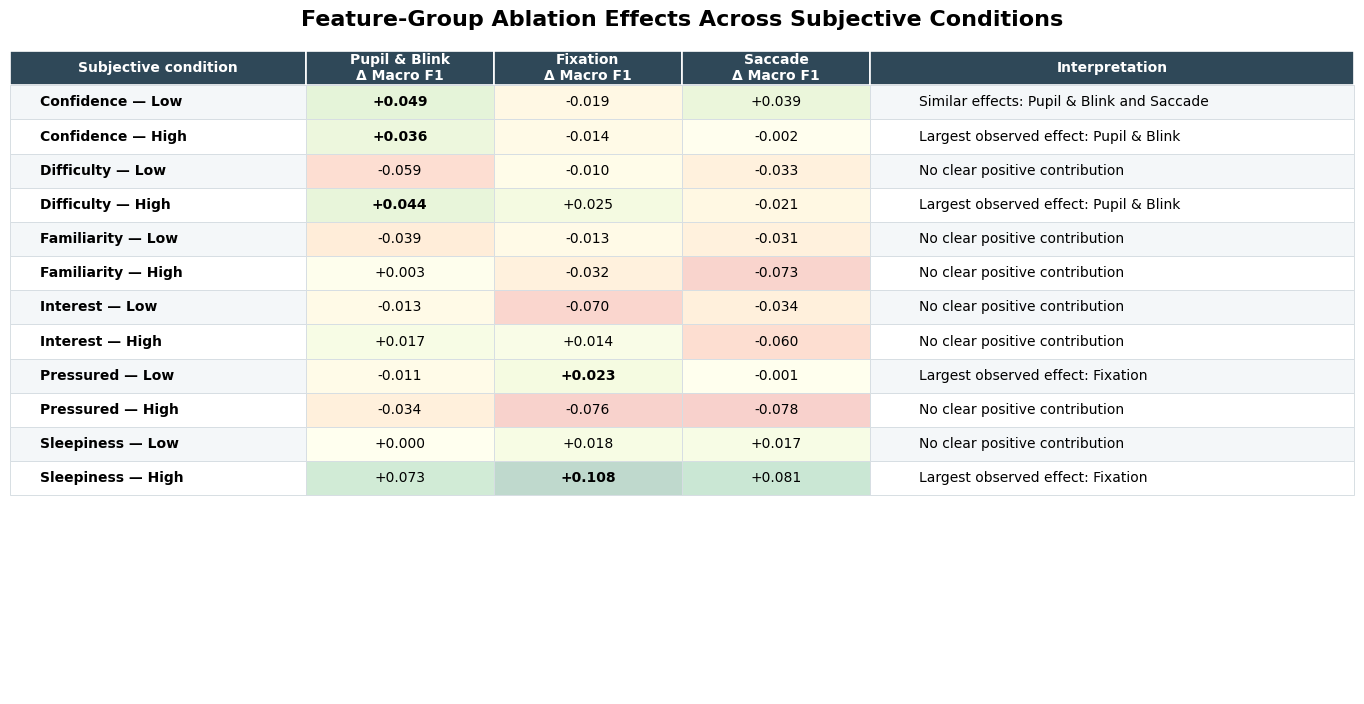

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm

RESULTS_PATH = "classification_ablation_results.csv"

results_df = pd.read_csv(RESULTS_PATH)


# 1. Prepare compact publication-style table

table_df = results_df[
    [
        "subset",
        "macro_f1_drop_without_pupil_blink",
        "macro_f1_drop_without_fixation",
        "macro_f1_drop_without_saccade"
    ]
].copy()

table_df = table_df.rename(
    columns={
        "macro_f1_drop_without_pupil_blink": "Pupil & Blink",
        "macro_f1_drop_without_fixation": "Fixation",
        "macro_f1_drop_without_saccade": "Saccade"
    }
)

def clean_condition_name(text):
    text = text.replace(": LOW 0-1", " — Low")
    text = text.replace(": HIGH 2-3", " — High")
    return text.title()

table_df["Condition"] = table_df["subset"].apply(
    clean_condition_name
)

table_df = table_df[
    [
        "Condition",
        "Pupil & Blink",
        "Fixation",
        "Saccade"
    ]
]

# 2. Add cautious interpretation

MIN_MEANINGFUL_EFFECT = 0.02
MIN_DIFFERENCE_BETWEEN_GROUPS = 0.01

def interpret_row(row):
    values = {
        "Pupil & Blink": row["Pupil & Blink"],
        "Fixation": row["Fixation"],
        "Saccade": row["Saccade"]
    }

    ranked = sorted(
        values.items(),
        key=lambda item: item[1],
        reverse=True
    )

    best_group, best_value = ranked[0]
    second_group, second_value = ranked[1]

    if best_value < MIN_MEANINGFUL_EFFECT:
        return "No clear positive contribution"

    if best_value - second_value < MIN_DIFFERENCE_BETWEEN_GROUPS:
        return (
            f"Similar effects: {best_group} and "
            f"{second_group}"
        )

    return f"Largest observed effect: {best_group}"

table_df["Interpretation"] = table_df.apply(
    interpret_row,
    axis=1
)

# 3. Create formatted text values

display_df = table_df.copy()

metric_columns = [
    "Pupil & Blink",
    "Fixation",
    "Saccade"
]

for column in metric_columns:
    display_df[column] = display_df[column].map(
        lambda value: f"{value:+.3f}"
    )

# 4. Draw the table

fig = plt.figure(figsize=(14, 8))

ax = fig.add_axes([0.02, 0.10, 0.96, 0.82])
ax.axis("off")

column_labels = [
    "Subjective condition",
    "Pupil & Blink\nΔ Macro F1",
    "Fixation\nΔ Macro F1",
    "Saccade\nΔ Macro F1",
    "Interpretation"
]

cell_text = display_df[
    [
        "Condition",
        "Pupil & Blink",
        "Fixation",
        "Saccade",
        "Interpretation"
    ]
].values.tolist()

table = ax.table(
    cellText=cell_text,
    colLabels=column_labels,
    cellLoc="center",
    colLoc="center",
    loc="upper center",
    colWidths=[0.22, 0.14, 0.14, 0.14, 0.36]
)

table.auto_set_font_size(False)
table.set_fontsize(10)

table.scale(1, 2.05)

# ---------- HEADER ----------
for col_index in range(len(column_labels)):
    header_cell = table[(0, col_index)]
    header_cell.set_text_props(
        weight="bold",
        color="white"
    )
    header_cell.set_facecolor("#2F4858")
    header_cell.set_edgecolor("white")
    header_cell.set_linewidth(1.2)

# ---------- BODY ----------
all_metric_values = table_df[metric_columns].to_numpy()
max_abs_value = np.abs(all_metric_values).max()

normalizer = TwoSlopeNorm(
    vmin=-max_abs_value,
    vcenter=0,
    vmax=max_abs_value
)

colormap = plt.get_cmap("RdYlGn")

for row_index in range(len(table_df)):
    table_row = row_index + 1

    base_color = (
        "#F4F7F9"
        if row_index % 2 == 0
        else "#FFFFFF"
    )

    for col_index in [0, 4]:
        cell = table[(table_row, col_index)]
        cell.set_facecolor(base_color)
        cell.set_edgecolor("#D7DEE3")
        cell.set_linewidth(0.7)

    table[(table_row, 0)].set_text_props(
        ha="left",
        weight="bold"
    )

    table[(table_row, 4)].set_text_props(
        ha="left"
    )

    row_values = table_df.iloc[row_index][metric_columns].astype(float)

    best_positive_group = row_values.idxmax()
    best_positive_value = row_values.max()

    for metric_position, metric_name in enumerate(metric_columns, start=1):

        value = row_values[metric_name]

        rgba = colormap(normalizer(value))

        softened_color = (
            0.75 + 0.25 * rgba[0],
            0.75 + 0.25 * rgba[1],
            0.75 + 0.25 * rgba[2]
        )

        cell = table[(table_row, metric_position)]

        cell.set_facecolor(softened_color)
        cell.set_edgecolor("#D7DEE3")
        cell.set_linewidth(0.7)

        if (
            metric_name == best_positive_group
            and best_positive_value >= MIN_MEANINGFUL_EFFECT
        ):
            cell.set_text_props(weight="bold")

# TITLE

fig.suptitle(
    "Feature-Group Ablation Effects Across Subjective Conditions",
    fontsize=16,
    fontweight="bold",
    y=0.955
)


plt.savefig(
    "ablation_summary_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "ablation_summary_table.pdf",
    bbox_inches="tight"
)

plt.show()